cuda


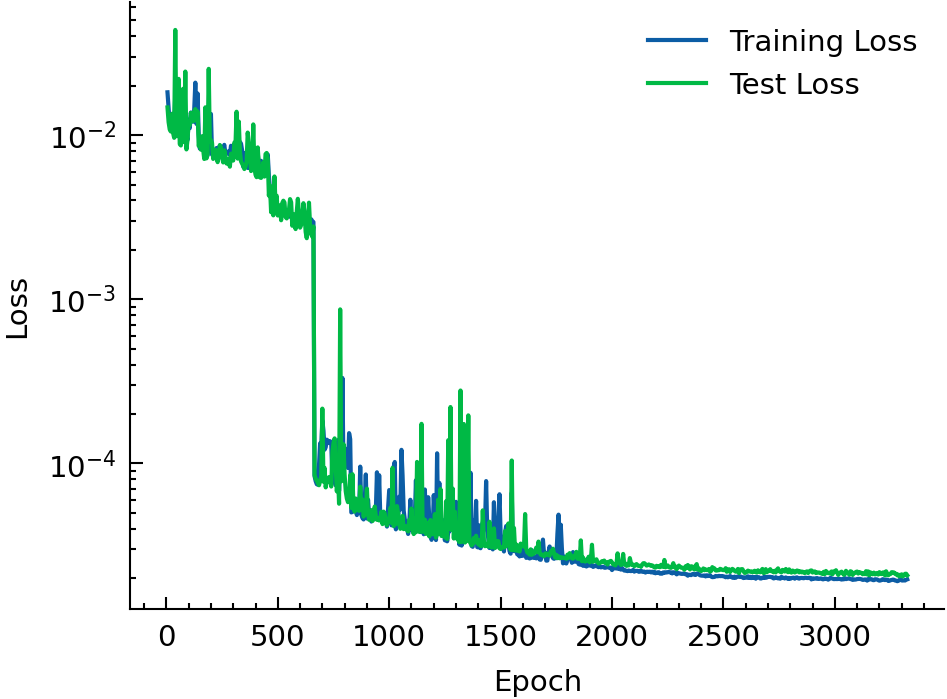

In [1]:
%reset -f

import torch
from plpm import PINN_CP, ModelWrapper, calculate_PLV, MainPlots
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

space_dim = 10
model_file = 'MainModel10DFinal'

main_model = ModelWrapper.Model(model_file=model_file, d=space_dim)

loss_file = 'losses10DFinal'

figures = MainPlots()
figures.plot_loss(loss_file)

In [2]:
# Model Evaluation
data_file = 'ND_10D_updatedBV'
pinn_cp = PINN_CP(num_timepoints=1, space_dimension=space_dim, num_cases=1)
_, NumData_DS = pinn_cp.build_NumericalDataDS(data_file=data_file)
sCASES_data = DataLoader(NumData_DS, batch_size=1)
total_error = torch.zeros((len(NumData_DS), 5))
i = 0
Scaling = main_model.Scaling

In [3]:
for sCASE, sV_num in sCASES_data:
    sV_num = sV_num.view(-1, 4)
    V_num = Scaling.InvVolScaler(sV_num)
    V_pred = main_model.predict_sCASE(sCASE, num_timepoints=V_num.shape[0])
    CASE_error = torch.mean(torch.abs(V_num - V_pred) / V_num, axis=0)
    print(CASE_error)
    total_error[i] = CASE_error
    i += 1

tensor([0.0058, 0.0076, 0.0166, 0.0077, 0.0188])
tensor([0.0181, 0.0031, 0.0017, 0.0011, 0.0063])
tensor([0.0271, 0.0227, 0.0167, 0.0063, 0.0093])
tensor([0.0135, 0.0085, 0.0061, 0.0040, 0.0153])
tensor([0.0084, 0.0079, 0.0156, 0.0083, 0.0268])
tensor([0.0244, 0.0100, 0.0078, 0.0024, 0.0199])
tensor([0.0063, 0.0015, 0.0016, 0.0006, 0.0012])
tensor([0.0170, 0.0080, 0.0172, 0.0089, 0.0282])
tensor([0.0259, 0.0072, 0.0090, 0.0057, 0.0238])
tensor([0.0427, 0.0224, 0.0177, 0.0066, 0.0101])
tensor([0.0222, 0.0313, 0.0283, 0.0140, 0.0393])
tensor([0.0291, 0.0189, 0.1336, 0.0446, 0.1013])
tensor([0.0184, 0.0137, 0.0153, 0.0072, 0.0263])
tensor([0.0269, 0.0440, 0.0173, 0.0069, 0.0145])
tensor([0.0546, 0.0653, 0.0511, 0.0188, 0.0376])
tensor([0.0386, 0.0140, 0.0155, 0.0075, 0.0260])
tensor([0.0284, 0.0200, 0.0364, 0.0173, 0.0493])
tensor([0.0172, 0.0052, 0.0029, 0.0021, 0.0080])
tensor([0.0155, 0.0136, 0.0178, 0.0063, 0.0205])
tensor([0.0082, 0.0133, 0.0092, 0.0038, 0.0096])
tensor([0.0091, 0.00

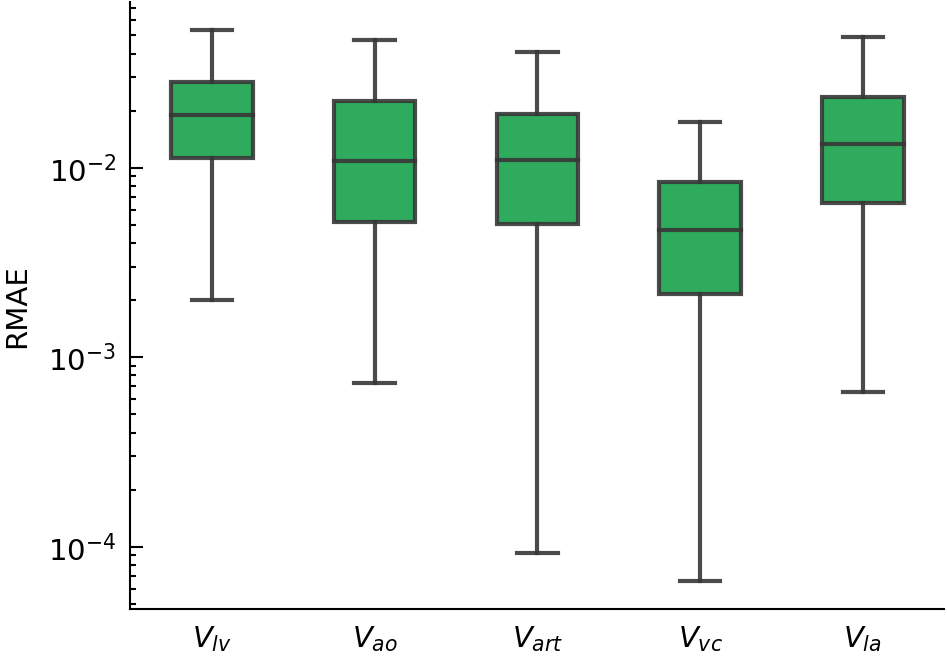

In [4]:
import seaborn as sns
fig, ax = plt.subplots()
sns.boxplot(total_error, ax=ax, showfliers=False, palette=['#00B945'],
                                                  boxprops={'alpha': 0.9},
                                                  whiskerprops={'alpha': 0.9},
                                                  medianprops={'alpha': 0.9},
                                                  capprops={'alpha': 0.9},
                                                  width=0.5)
ax.set_ylabel('RMAE')
ax.set_yscale('log')
ax.set_xticklabels(['$V_{lv}$', '$V_{ao}$', '$V_{art}$', '$V_{vc}$', '$V_{la}$'])

ax.tick_params(
    axis='x',       # Apply changes to x  axes
    which='both',   # Apply changes to both major and minor ticks
    bottom=False,   # Show or hide ticks on the bottom side
)

plt.show(fig)

In [7]:
top10errors = torch.topk(total_error, k=5, dim=0)
top10errors

torch.return_types.topk(
values=tensor([[0.0973, 0.2105, 0.1440, 0.0538, 0.1057],
        [0.0893, 0.1903, 0.1341, 0.0527, 0.1013],
        [0.0803, 0.1117, 0.1336, 0.0519, 0.0969],
        [0.0793, 0.0968, 0.1327, 0.0446, 0.0952],
        [0.0764, 0.0932, 0.0940, 0.0347, 0.0936]]),
indices=tensor([[261, 918, 932, 918, 219],
        [243, 459, 459, 932,  11],
        [165, 583,  11, 459, 932],
        [363, 243, 918,  11, 459],
        [728, 947, 186, 219, 918]]))

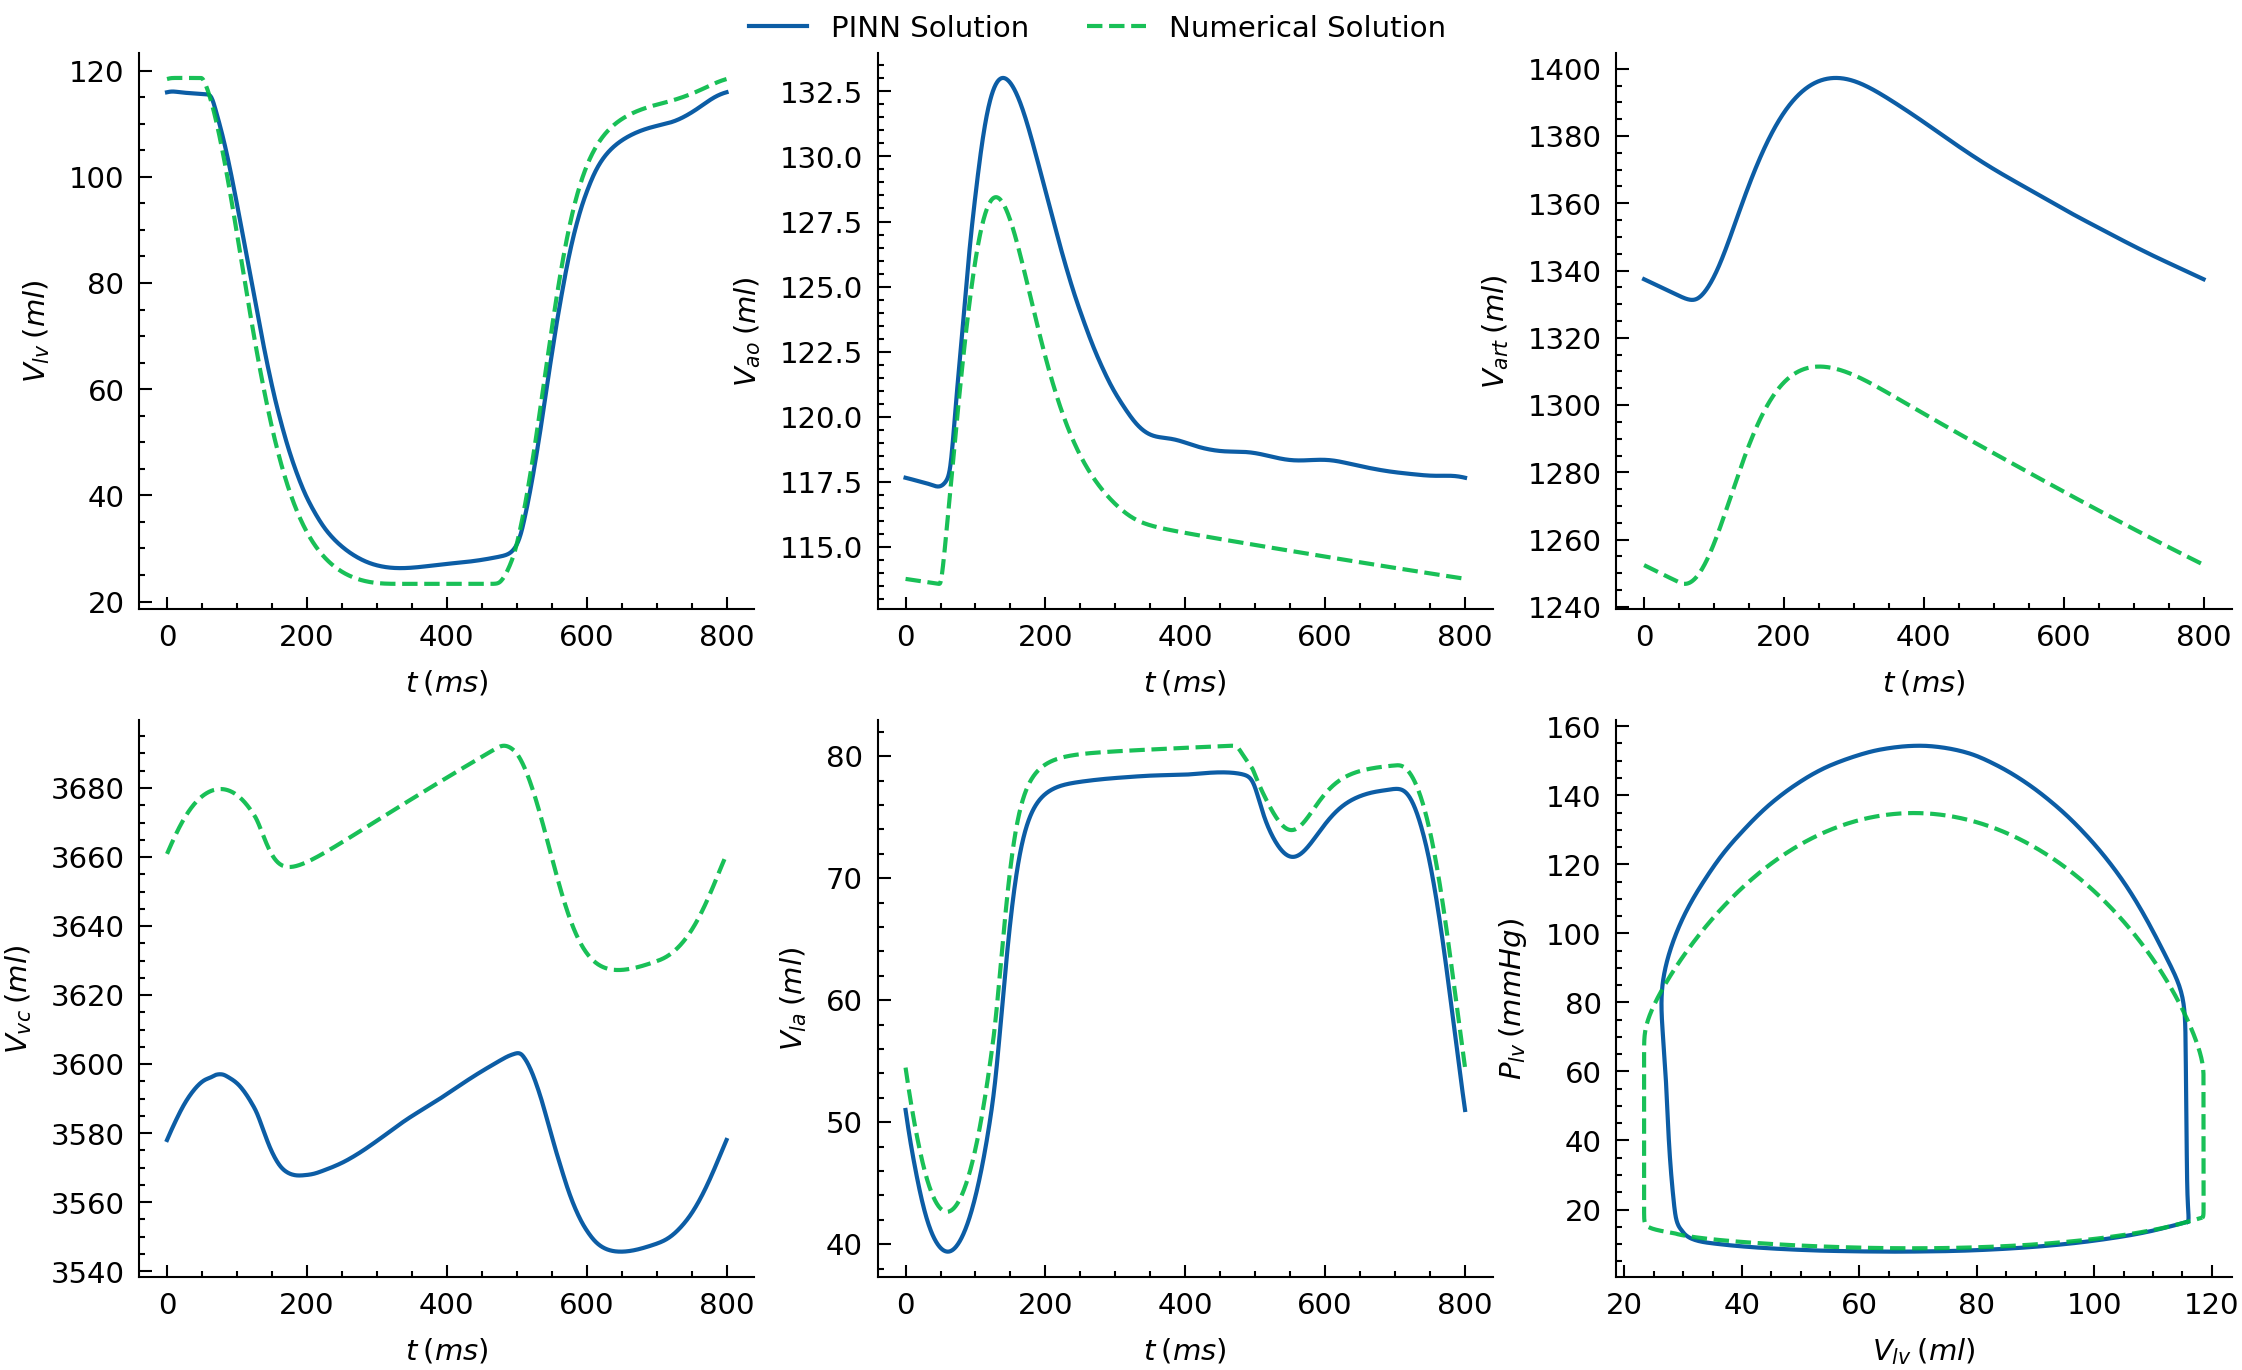

In [11]:
sCASE = sCASES_data.dataset[261][0]
sV_num = sCASES_data.dataset[261][1]
sCASE, sV_num = sCASE, sV_num
V_num = Scaling.InvVolScaler(sV_num)
V_pred = main_model.predict_sCASE(sCASE, num_timepoints=V_num.shape[0])

CASE = Scaling.InvCaseScaler(sCASE.reshape((1, -1))).detach().cpu()
plv_pinn = calculate_PLV(V_pred[:, 0], CASE[:, -2], CASE[:, -1])
plv_num = calculate_PLV(V_num[:, 0], CASE[:, -2], CASE[:, -1])

figures.plot_CASE_together(V_pred, plv_pinn, V_num, plv_num)